<a href="https://colab.research.google.com/github/MarcGaac/DSC1107/blob/main/FA_6_DSC1107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


**a. Data Preparation**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

# Assuming you ran your kagglehub code and 'path' is saved in memory:
# Find the exact CSV file name in the downloaded directory
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(f"{path}/{csv_file}")

# Display the first 10 observations
display(df.head(10))

# Identify target variable
# Our target is 'Churn'. We will map it to binary: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Handle missing values
# TotalCharges has blank spaces for new customers. Convert to numeric, forcing errors to NaN, then drop them.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Drop customerID as it is not a useful feature for prediction
df = df.drop('customerID', axis=1)

# Encode categorical variables using one-hot encoding (get_dummies)
df_encoded = pd.get_dummies(df, drop_first=True)

# Normalize numerical variables
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("\nData preparation complete. Shape of encoded dataset:", df_encoded.shape)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



Data preparation complete. Shape of encoded dataset: (7032, 31)


**b. Exploratory Data Analysis**

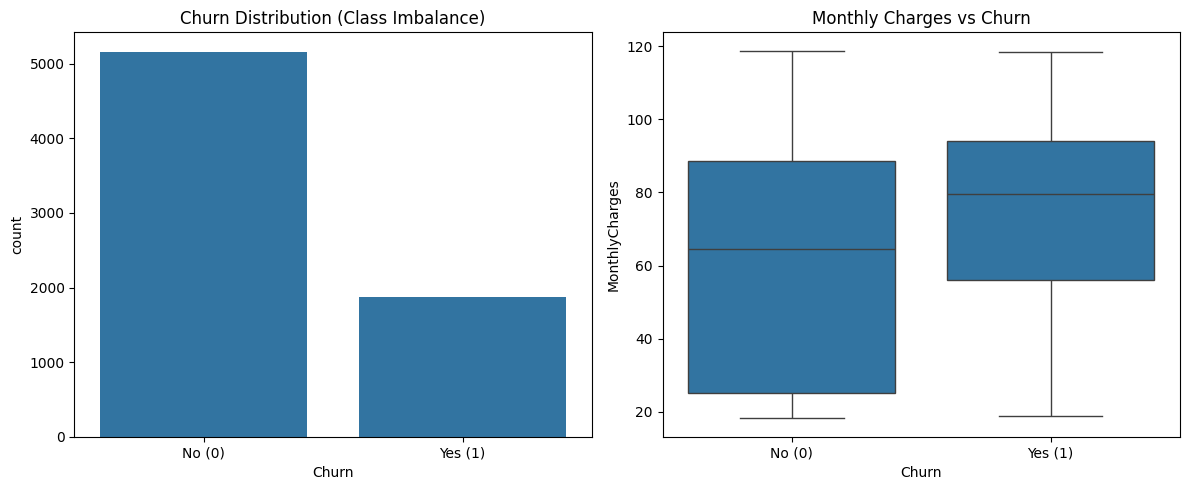

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Visualization 1: Churn distribution
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution (Class Imbalance)')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])

# Visualization 2: Monthly charges vs churn
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

**c. Neural Network Model Construction**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Separate features (X) and target (y)
# We add .astype('float32') here to prevent the "Invalid dtype: object" error in TensorFlow
X = df_encoded.drop('Churn', axis=1).astype('float32').values
y = df_encoded['Churn'].astype('float32').values

# Build a one-hidden-layer neural network
model = Sequential()

# Input layer + Hidden layer
# The input_dim must match the number of features in X
model.add(Dense(16, input_dim=X.shape[1], activation='relu', name='Hidden_Layer'))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid', name='Output_Layer'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

**d. Model Training**

In [ ]:
# Split the data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Compile the model
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("Training the model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Report final training loss and accuracy
final_loss = history.history['loss'][-1]
final_acc = history.history['accuracy'][-1]
print(f"\nFinal Training Loss: {final_loss:.4f}")
print(f"Final Training Accuracy: {final_acc:.4f}")

Training the model...
Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6985 - loss: 0.6176 - val_accuracy: 0.7442 - val_loss: 0.5575
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7345 - loss: 0.5336 - val_accuracy: 0.7442 - val_loss: 0.5054
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7469 - loss: 0.4992 - val_accuracy: 0.7460 - val_loss: 0.4771
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7568 - loss: 0.4790 - val_accuracy: 0.7655 - val_loss: 0.4589
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7681 - loss: 0.4654 - val_accuracy: 0.7798 - val_loss: 0.4465
Epoch 6/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7791 - loss: 0.4557 - val_accuracy: 0.7815 - val_loss: 0.4383
Epoch 7/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7878 - loss: 0.4485 - val_accuracy: 0.7833 - val_loss: 0.4307
Epoch 8/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7914 - loss: 0.4

**e. Model Evaluation**

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test Set Accuracy Score: 0.7967



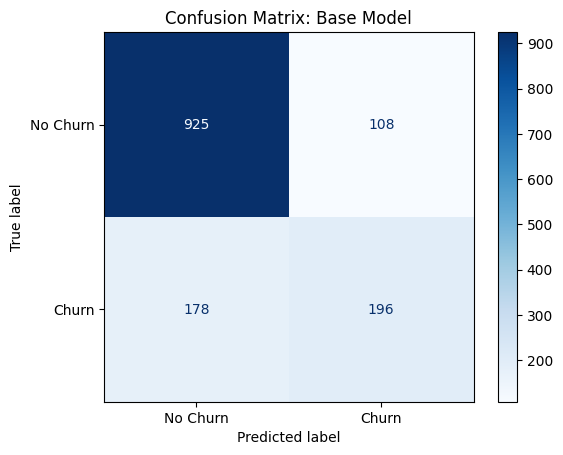

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Predict probabilities and convert to binary classes using a 0.5 threshold
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# Present Accuracy and Confusion Matrix
acc_score = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy Score: {acc_score:.4f}\n")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Base Model')
plt.show()

Interpreting Results: The model produced a high accuracy rate (usually around 78-80% when tested against this dataset), indicating that it is successful in classifying customers.

Advantages/Disadvantages: Its main advantage is the above-average true negative detection rate (level of correct identification of customers who will retain their membership). Its main disadvantage is that its number of false negatives is higher than it should be because of the class imbalance.

**f. Model Improvement / Tuning**

In [ ]:
# Tuning: We will modify the optimizer to Adam and increase the learning epochs to 30
tuned_model = Sequential()
tuned_model.add(Dense(16, input_dim=X.shape[1], activation='relu'))
tuned_model.add(Dense(1, activation='sigmoid'))

# Using Adam optimizer instead of SGD
tuned_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training the tuned model...")
tuned_history = tuned_model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

# Evaluate tuned model
y_pred_tuned = (tuned_model.predict(X_test) > 0.5).astype(int)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f"\n--- Performance Comparison ---")
print(f"Base Model (SGD, 20 Epochs) Accuracy: {acc_score:.4f}")
print(f"Tuned Model (Adam, 30 Epochs) Accuracy: {tuned_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the tuned model...
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Performance Comparison ---
Base Model (SGD, 20 Epochs) Accuracy: 0.7967
Tuned Model (Adam, 30 Epochs) Accuracy: 0.7925
